# Step 1: Importing Required Libraries

In this step, we import all the libraries required for data analysis, visualization, machine learning, and time series forecasting.

In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.holtwinters import ExponentialSmoothing

import warnings
warnings.filterwarnings("ignore")

# Step 2: Loading the Dataset

In this step, the dataset is loaded into a pandas DataFrame to understand its structure and contents.

In [26]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [27]:
df.shape

(2640, 12)

In [28]:
print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Column Names:
Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_T

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000



Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows:
0


# Step 3: Data Preprocessing

Data preprocessing is an important step before building a machine learning model. In this step, duplicate records are removed, categorical columns are converted into numerical values, and the dataset is prepared for further analysis.

In [29]:
df.drop_duplicates(inplace=True)

encoder = LabelEncoder()

df["Region"] = encoder.fit_transform(df["Region"])
df["Model"] = encoder.fit_transform(df["Model"])
df["Source_Type"] = encoder.fit_transform(df["Source_Type"])

print("Shape after removing duplicates:", df.shape)

display(df.head())

Shape after removing duplicates: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


# Step 4: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the dataset, identify patterns, and analyze the relationships between different features using visualizations.

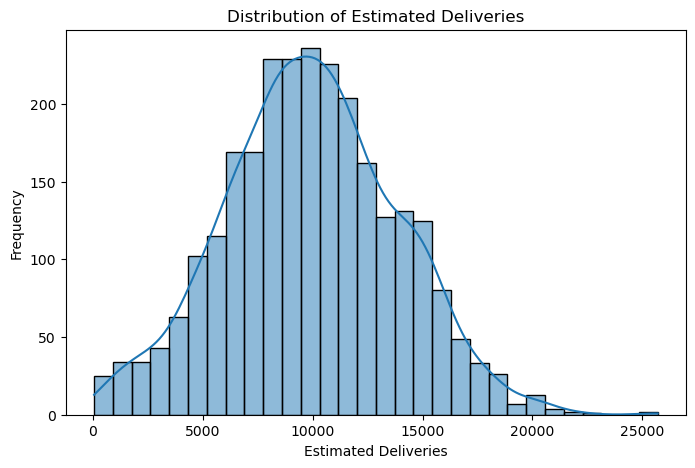

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df["Estimated_Deliveries"], bins=30, kde=True)
plt.title("Distribution of Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")
plt.show()

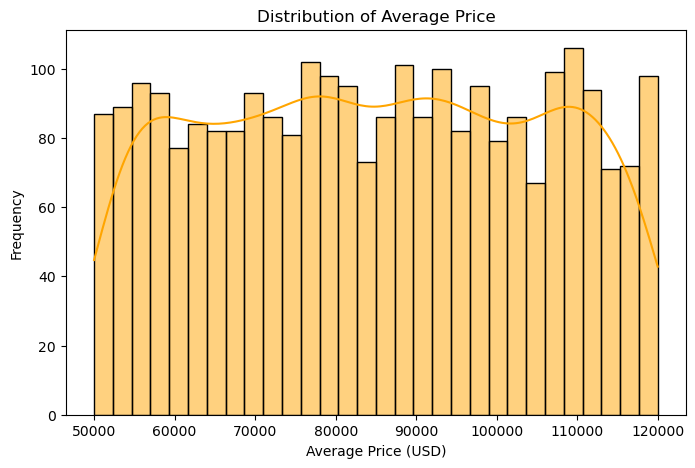

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df["Avg_Price_USD"], bins=30, color="orange", kde=True)
plt.title("Distribution of Average Price")
plt.xlabel("Average Price (USD)")
plt.ylabel("Frequency")
plt.show()

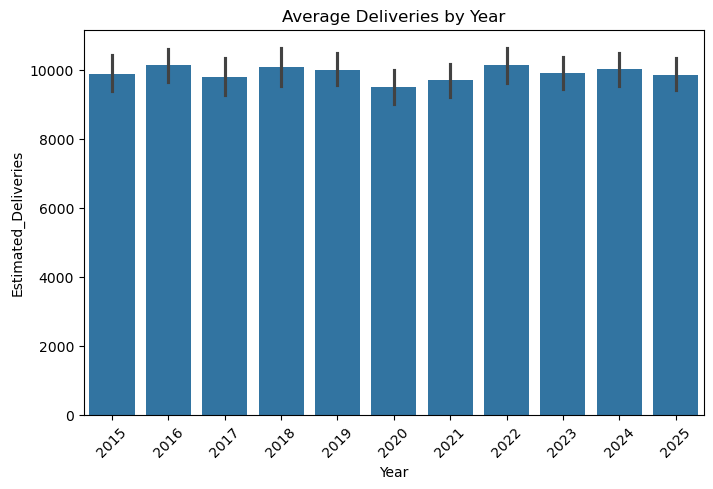

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(x="Year", y="Estimated_Deliveries", data=df)
plt.title("Average Deliveries by Year")
plt.xticks(rotation=45)
plt.show()

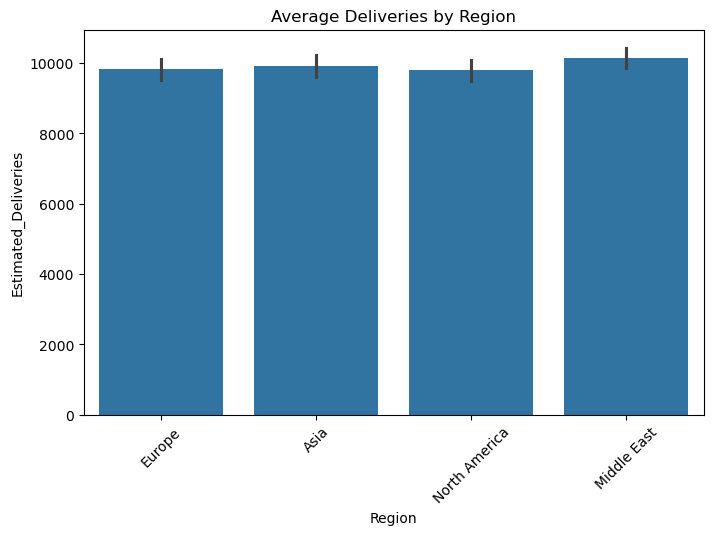

In [33]:
region_data = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

plt.figure(figsize=(8,5))
sns.barplot(x="Region", y="Estimated_Deliveries", data=region_data)
plt.title("Average Deliveries by Region")
plt.xticks(rotation=45)
plt.show()

### Correlation Heatmap

A correlation heatmap is used to understand the relationship between numerical features in the dataset.

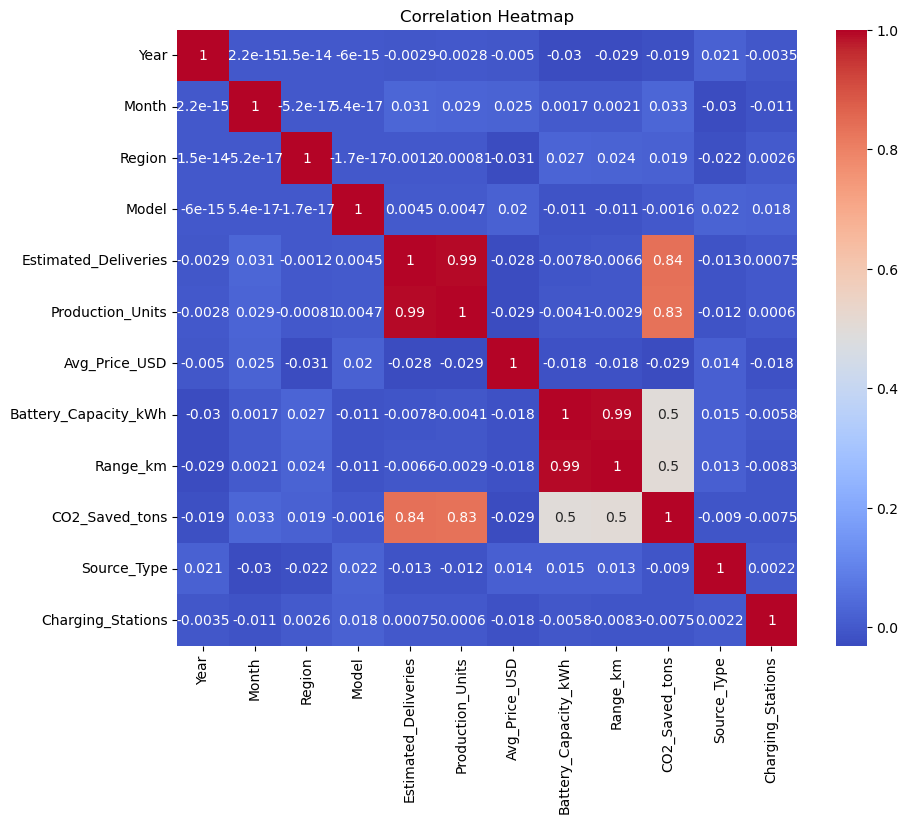

In [34]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

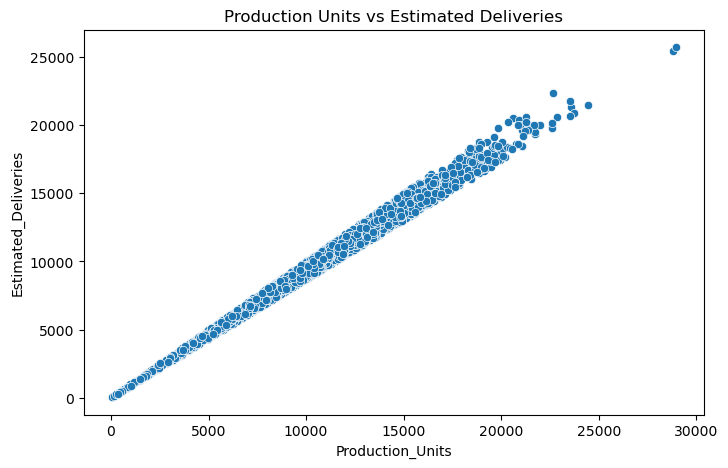

In [35]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Production_Units", y="Estimated_Deliveries", data=df)
plt.title("Production Units vs Estimated Deliveries")
plt.show()

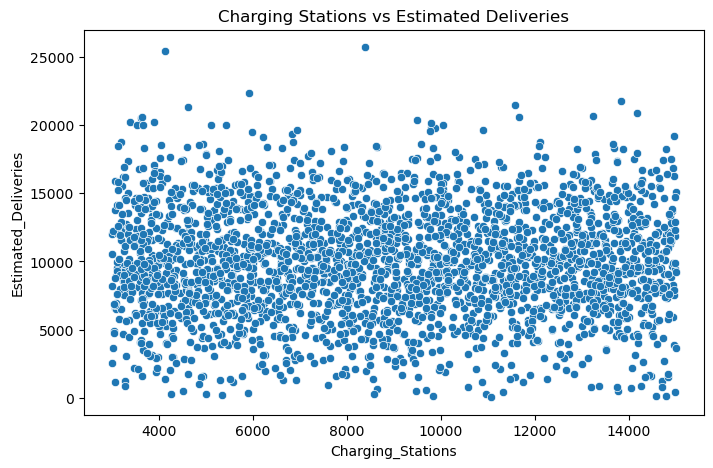

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Charging_Stations", y="Estimated_Deliveries", data=df)
plt.title("Charging Stations vs Estimated Deliveries")
plt.show()

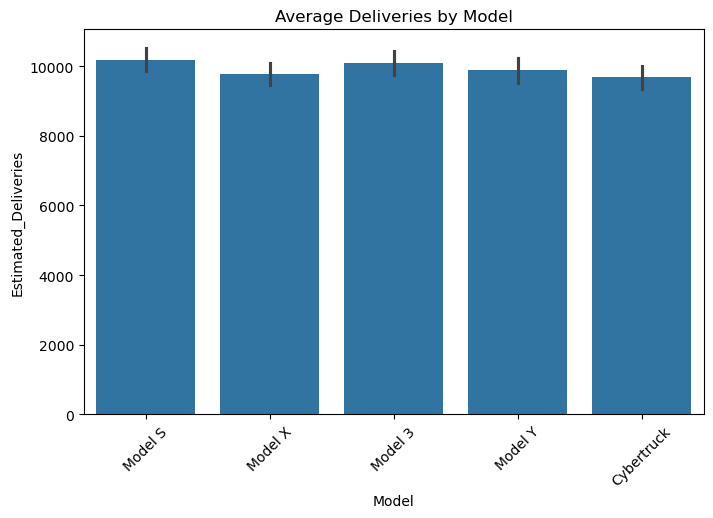

In [37]:
model_data = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Estimated_Deliveries", data=model_data)
plt.title("Average Deliveries by Model")
plt.xticks(rotation=45)
plt.show()

# Step 5: Feature Engineering

Feature engineering is the process of creating new features from existing data to improve the performance of machine learning models. In this project, a few meaningful features are created based on the existing columns.

In [38]:
df["Price_per_km"] = df["Avg_Price_USD"] / df["Range_km"]

df["Production_Delivery_Ratio"] = df["Estimated_Deliveries"] / df["Production_Units"]

df["Charging_per_Delivery"] = df["Charging_Stations"] / df["Estimated_Deliveries"]

display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Price_per_km,Production_Delivery_Ratio,Charging_per_Delivery
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,131.923679,0.984600,0.691772
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,142.022032,0.911864,2.012115
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,245.598583,0.915334,1.672928
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,125.414199,0.896594,1.423799
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,173.747020,0.914087,0.704865


# Step 6: Regression Modeling

In this step, the dataset is divided into training and testing sets. A Random Forest Regressor is trained to predict the estimated deliveries using the available features.

In [39]:
df_model = df.drop(columns=["Production_Delivery_Ratio", "Charging_per_Delivery"])

X = df_model.drop("Estimated_Deliveries", axis=1)
y = df_model["Estimated_Deliveries"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("Model trained successfully!")

Model trained successfully!


# Step 7: Model Evaluation

The performance of the trained model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [40]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Mean Absolute Error (MAE): 326.58
Root Mean Squared Error (RMSE): 412.02
R² Score: 0.9886


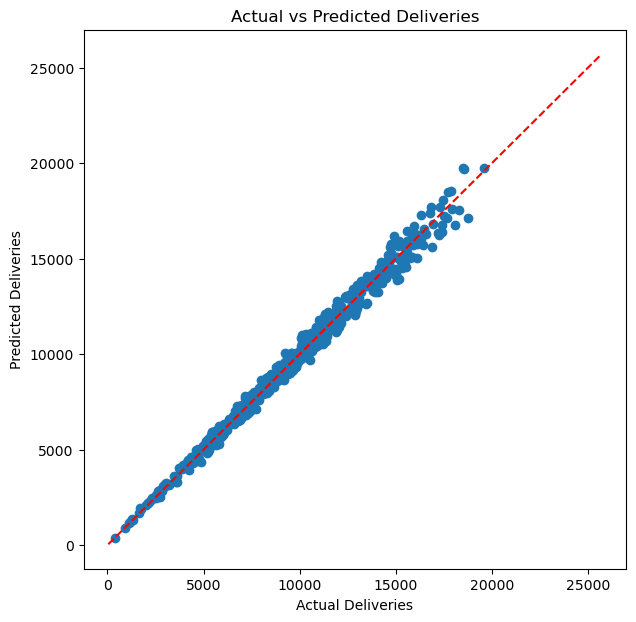

In [41]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, predictions)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")
plt.show()

# Step 8: Hyperparameter Tuning

In this step, we use GridSearchCV to find the best parameters for the Random Forest model. This helps improve the model's accuracy by trying different combinations of settings.

In [42]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R² Score (CV):", round(grid_search.best_score_, 4))

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best R² Score (CV): 0.9879


In [ ]:
best_model = grid_search.best_estimator_

best_predictions = best_model.predict(X_test)

mae = mean_absolute_error(y_test, best_predictions)
rmse = np.sqrt(mean_squared_error(y_test, best_predictions))
r2 = r2_score(y_test, best_predictions)

print("Improved Model Results:")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R² Score:", round(r2, 4))

Improved Model Results:
Mean Absolute Error (MAE): 325.08
Root Mean Squared Error (RMSE): 410.76
R² Score: 0.9887


# Step 9: Feature Importance

Feature importance tells us which features had the most impact on the model's predictions. This helps us understand what factors affect Tesla deliveries the most.

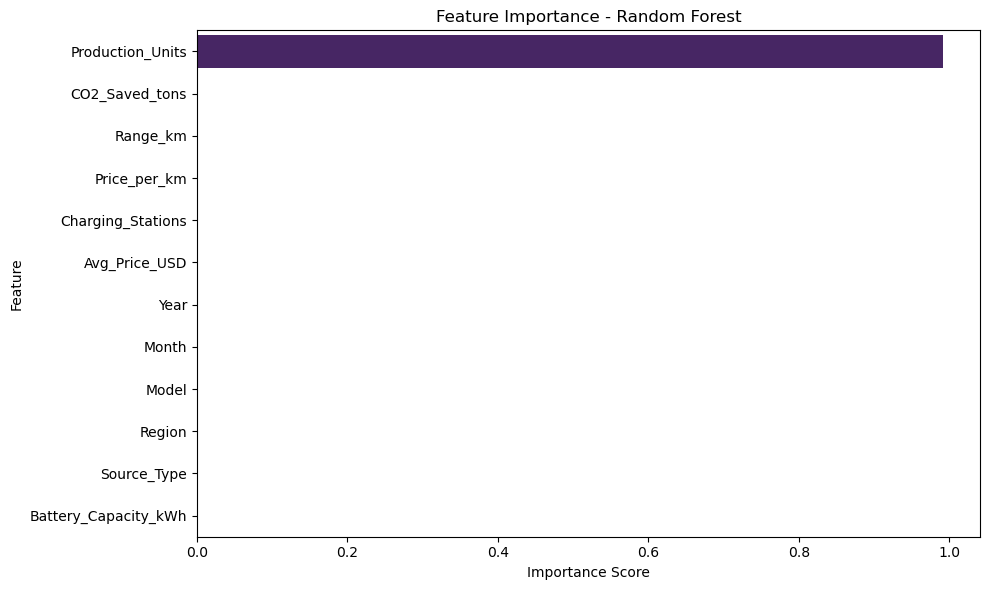

                 Feature  Importance
4       Production_Units    0.991296
8         CO2_Saved_tons    0.002199
7               Range_km    0.001150
11          Price_per_km    0.000978
10     Charging_Stations    0.000962
5          Avg_Price_USD    0.000960
0                   Year    0.000734
1                  Month    0.000636
3                  Model    0.000400
2                 Region    0.000334
9            Source_Type    0.000247
6   Battery_Capacity_kWh    0.000105


In [44]:
feature_names = X.columns
importances = best_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feat_df)

# Step 10: Time Series Forecasting



In [45]:
ts_data = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")


print("Columns in dataset:", ts_data.columns.tolist())


if 'Quarter' in ts_data.columns:
    ts_data['Quarter'] = ts_data['Quarter'].str.replace('Q', '').astype(int)
    quarterly = ts_data.groupby(['Year', 'Quarter'])['Estimated_Deliveries'].sum().reset_index()
    quarterly = quarterly.sort_values(['Year', 'Quarter']).reset_index(drop=True)
elif 'quarter' in [c.lower() for c in ts_data.columns]:
    
    q_col = [c for c in ts_data.columns if c.lower() == 'quarter'][0]
    ts_data[q_col] = ts_data[q_col].astype(str).str.replace('Q', '').astype(int)
    quarterly = ts_data.groupby(['Year', q_col])['Estimated_Deliveries'].sum().reset_index()
    quarterly = quarterly.sort_values(['Year', q_col]).reset_index(drop=True)
else:
   
    print("No Quarter column found. Grouping by Year instead.")
    quarterly = ts_data.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
    quarterly = quarterly.sort_values('Year').reset_index(drop=True)

delivery_series = quarterly['Estimated_Deliveries']

print("Total data points:", len(delivery_series))
print(delivery_series.tail(8))

Columns in dataset: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
No Quarter column found. Grouping by Year instead.
Total data points: 11
3     2423104
4     2404230
5     2280336
6     2335116
7     2434220
8     2382375
9     2406899
10    2368462
Name: Estimated_Deliveries, dtype: int64


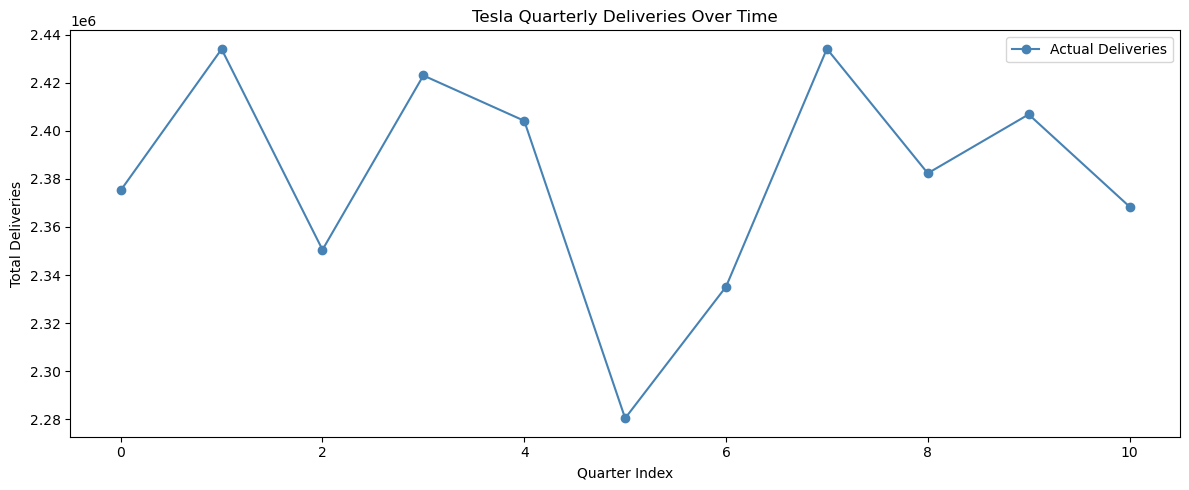

In [46]:

plt.figure(figsize=(12, 5))
plt.plot(delivery_series.values, marker='o', color='steelblue', label='Actual Deliveries')
plt.title('Tesla Quarterly Deliveries Over Time')
plt.xlabel('Quarter Index')
plt.ylabel('Total Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
n_points = len(delivery_series)
seasonal_periods = 4 if n_points >= 8 else 2

hw_model = ExponentialSmoothing(
    delivery_series,
    trend='add',
    seasonal='add' if n_points >= seasonal_periods * 2 else None,
    seasonal_periods=seasonal_periods if n_points >= seasonal_periods * 2 else None
)

hw_fit = hw_model.fit()

forecast_steps = 4
forecast = hw_fit.forecast(forecast_steps)

print("Forecasted Deliveries for Next 4 Periods:")
for i, val in enumerate(forecast, 1):
    print(f"  Period {i}: {int(val):,}")

Forecasted Deliveries for Next 4 Periods:
  Period 1: 2,403,756
  Period 2: 2,358,177
  Period 3: 2,385,489
  Period 4: 2,322,690


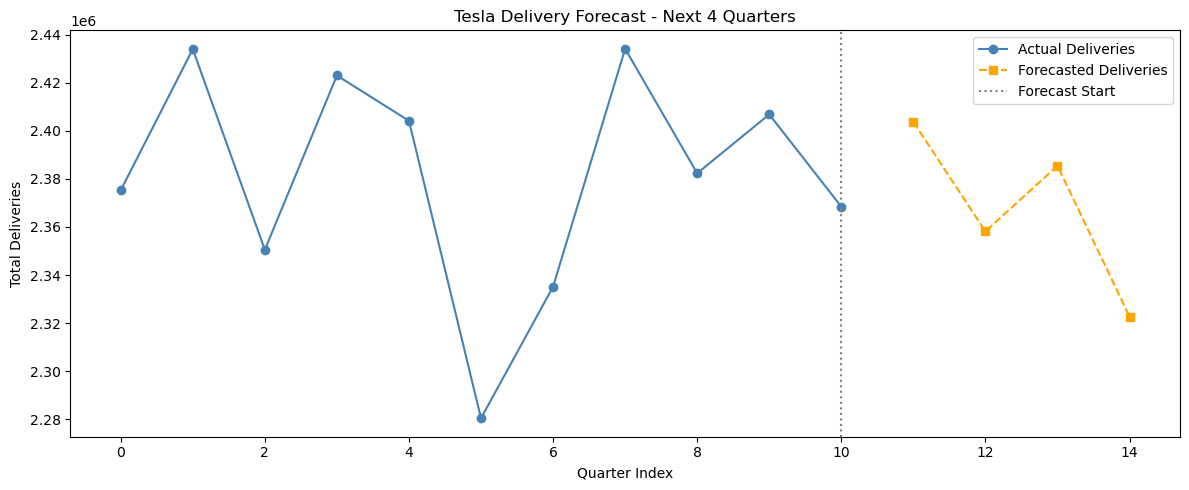

In [48]:
plt.figure(figsize=(12, 5))

plt.plot(delivery_series.values, marker='o', color='steelblue', label='Actual Deliveries')

forecast_index = range(len(delivery_series), len(delivery_series) + forecast_steps)
plt.plot(forecast_index, forecast.values, marker='s', color='orange', linestyle='--', label='Forecasted Deliveries')

plt.axvline(x=len(delivery_series) - 1, color='gray', linestyle=':', label='Forecast Start')
plt.title('Tesla Delivery Forecast - Next 4 Quarters')
plt.xlabel('Quarter Index')
plt.ylabel('Total Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

# Step 11: Conclusion

In this project, we analyzed Tesla's delivery data from 2015 to 2025 and built a complete machine learning pipeline.


### What I Did:
- **Loaded and explored** the Tesla deliveries dataset
- **Preprocessed** the data by removing duplicates and encoding categorical columns
- **Performed EDA** to understand delivery trends across years, regions, and models
- **Engineered new features** like Price per km and Production-Delivery Ratio
- **Built a Random Forest Regressor** to predict estimated deliveries
- **Evaluated the model** using MAE, RMSE, and R² Score
- **Tuned the model** using GridSearchCV to improve accuracy
- **Analyzed feature importance** to find the most influential factors
- **Forecasted future deliveries** using Holt-Winters Exponential Smoothing


